LAB 7: Edge-Cloud Hybrid Inference

Dataset: Iris
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Shape: (150, 4)

Feature Transformation (StandardScaler)
Before scaling - Mean: 3.479761904761905
Before scaling - Std: 1.9918392889072318
After scaling - Mean: 2.7068294695622867e-16
After scaling - Std: 1.0

Running Hybrid Inference (Threshold = 0.85)
------------------------------------------------------------
Sample  1: True=virginica  EdgeConf=0.899 Decision=EDGE  Pred=virginica
Sample  2: True=versicolor EdgeConf=0.789 Decision=CLOUD Pred=versicolor
Sample  3: True=virginica  EdgeConf=0.620 Decision=CLOUD Pred=versicolor
Sample  4: True=versicolor EdgeConf=0.629 Decision=CLOUD Pred=versicolor
Sample  5: True=virginica  EdgeConf=0.610 Decision=CLOUD Pred=virginica
Sample  6: True=virginica  EdgeConf=0.978 Decision=EDGE  Pred=virginica
Sample  7: True=versicolor EdgeConf=0.915 Decision=EDGE  Pred=

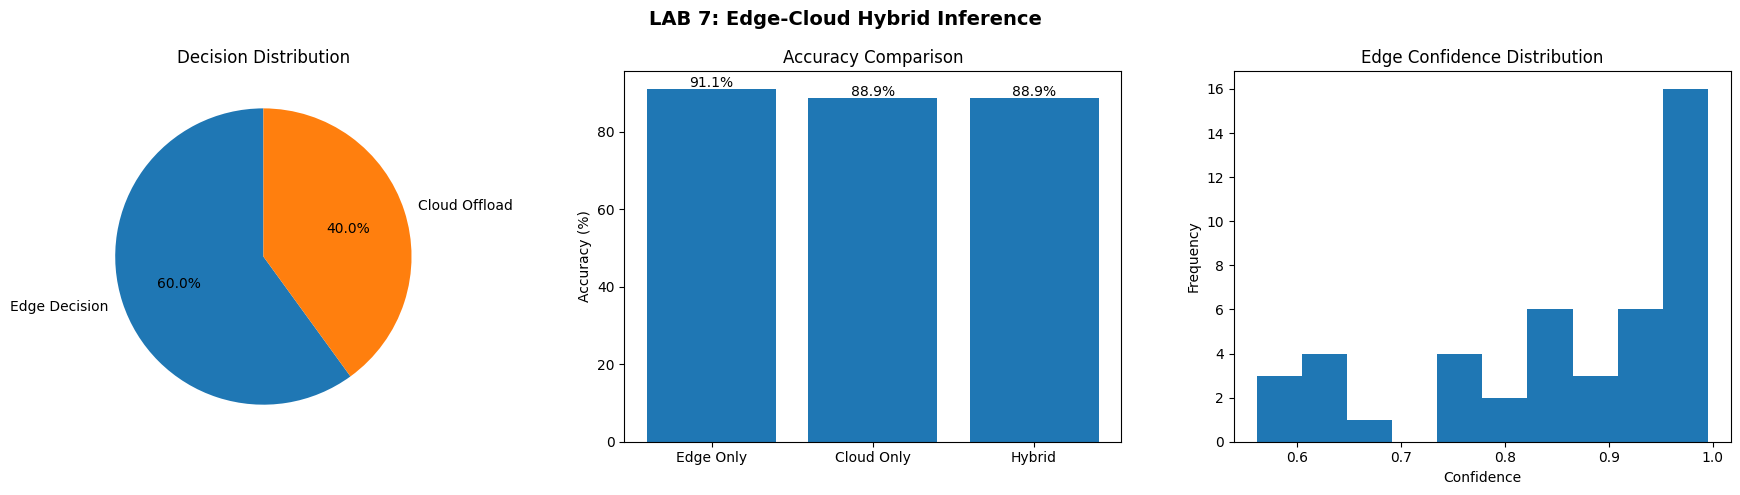

In [3]:

# LAB 7: Edge-to-Cloud Hybrid Inference with Dataset Transformations

import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


print("="*60)
print("LAB 7: Edge-Cloud Hybrid Inference")
print("="*60)


# STEP 1: Load and Explore Dataset

data = load_iris()

X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

print("\nDataset: Iris")
print("Features:", feature_names)
print("Classes:", class_names)
print("Shape:", X.shape)


# STEP 2: Dataset Transformation (Preprocessing)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Demonstrate StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature Transformation (StandardScaler)")
print("Before scaling - Mean:", X_train.mean())
print("Before scaling - Std:", X_train.std())
print("After scaling - Mean:", X_train_scaled.mean())
print("After scaling - Std:", X_train_scaled.std())


# STEP 3: EDGE MODEL — Logistic Regression

edge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200, random_state=42))
])

edge_pipeline.fit(X_train, y_train)


# STEP 4: CLOUD MODEL — Random Forest

cloud_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

cloud_pipeline.fit(X_train, y_train)


# STEP 5: Hybrid Inference with Thresholding

CONFIDENCE_THRESHOLD = 0.85

results = {
    "edge_decided": 0,
    "cloud_offloaded": 0,
    "edge_correct": 0,
    "cloud_correct": 0,
    "edge_latencies": [],
    "cloud_latencies": []
}

hybrid_predictions = []

print(f"\nRunning Hybrid Inference (Threshold = {CONFIDENCE_THRESHOLD})")
print("-"*60)


for i, (sample, true_label) in enumerate(zip(X_test, y_test)):

    sample_2d = sample.reshape(1, -1)

    # Edge inference
    t_start = time.perf_counter()

    edge_proba = edge_pipeline.predict_proba(sample_2d)[0]
    edge_conf = np.max(edge_proba)
    edge_pred = np.argmax(edge_proba)

    edge_time = (time.perf_counter() - t_start) * 1000

    if edge_conf >= CONFIDENCE_THRESHOLD:

        results["edge_decided"] += 1
        results["edge_latencies"].append(edge_time)

        if edge_pred == true_label:
            results["edge_correct"] += 1

        final_pred = edge_pred
        source = "EDGE"

    else:
        # Offload to cloud
        t_start = time.perf_counter()

        cloud_proba = cloud_pipeline.predict_proba(sample_2d)[0]
        cloud_pred = np.argmax(cloud_proba)

        cloud_time = (time.perf_counter() - t_start) * 1000

        results["cloud_offloaded"] += 1
        results["cloud_latencies"].append(edge_time + cloud_time)

        if cloud_pred == true_label:
            results["cloud_correct"] += 1

        final_pred = cloud_pred
        source = "CLOUD"

    hybrid_predictions.append(final_pred)

    if i < 10:
        print(
            f"Sample {i+1:2d}: True={class_names[true_label]:10s} "
            f"EdgeConf={edge_conf:.3f} "
            f"Decision={source:5s} "
            f"Pred={class_names[final_pred]}"
        )


# STEP 6: Results Summary

total = len(y_test)

hybrid_acc = accuracy_score(y_test, hybrid_predictions)
edge_only_acc = accuracy_score(y_test, edge_pipeline.predict(X_test))
cloud_only_acc = accuracy_score(y_test, cloud_pipeline.predict(X_test))

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)

print("Total Test Samples:", total)

print("Edge Decided:",
      results["edge_decided"],
      f"({results['edge_decided']/total*100:.1f}%)")

print("Cloud Offloaded:",
      results["cloud_offloaded"],
      f"({results['cloud_offloaded']/total*100:.1f}%)")

print(f"\nHybrid Accuracy: {hybrid_acc*100:.2f}%")
print(f"Edge-Only Accuracy: {edge_only_acc*100:.2f}%")
print(f"Cloud-Only Accuracy: {cloud_only_acc*100:.2f}%")

if results["edge_latencies"]:
    print("Avg Edge Latency:",
          f"{np.mean(results['edge_latencies']):.3f} ms")

if results["cloud_latencies"]:
    print("Avg Cloud Latency:",
          f"{np.mean(results['cloud_latencies']):.3f} ms")


# STEP 7: Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("LAB 7: Edge-Cloud Hybrid Inference", fontsize=14, fontweight="bold")


# Plot 1: Decision distribution

axes[0].pie(
    [results["edge_decided"], results["cloud_offloaded"]],
    labels=["Edge Decision", "Cloud Offload"],
    autopct="%1.1f%%",
    startangle=90
)

axes[0].set_title("Decision Distribution")


# Plot 2: Accuracy comparison

models = ["Edge Only", "Cloud Only", "Hybrid"]
accuracies = [edge_only_acc*100, cloud_only_acc*100, hybrid_acc*100]

axes[1].bar(models, accuracies)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Comparison")

for i, a in enumerate(accuracies):
    axes[1].text(i, a+0.5, f"{a:.1f}%", ha='center')


# Plot 3: Edge confidence distribution

confidences = np.max(edge_pipeline.predict_proba(X_test), axis=1)

axes[2].hist(confidences, bins=10)
axes[2].set_xlabel("Confidence")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Edge Confidence Distribution")


plt.tight_layout()
plt.show()